# Step 3: Forecast Visualization Outputs
Lindsay Fitzpatrick
ljob@umich.edu

**Initial Version:** 06/16/2026
**Updated:** 07/27/2026 

This script reads in forecast data generated from **2_LEF_forecast_model** and saved in the **cfs_forecast.db** database. It creates several figures to make the 12-month forecast easier and faster interpretation.

### Required Files

- **`cnbs_forecast.db`**
  This file holds the forecast for **precipitation**, **evaporation**, **runoff**, and **net basin supply** created from **`Script 2`**.

- **`climatology_exceedance_probability.csv`**

  This file contains **net basin supply** and the cooresponding **climatology exceedance probability** calculated in **`Script 2`** using the **probability of exceedance** files from USACE.
  
### Required Forecast DataFrame Format

The plotting functions require the **`cnbs_forecast.db`** to be in **long format**. Each row should represent a single forecast value for a given:

- CFS forecast initialization time (`cfs_run`)
- forecast month (`forecast_month`)
- model
- lake
- forecast component

Example dataframe:

| cfs_run | forecast_month | model | lake | component | value [mm] | value [cms] |
|---------|----------------|-------|------|-----------|------------|-------------|
| 2025101700 | 2026-07 | GP | erie | precipitation | 50.89 | 487.45 |
| 2025101700 | 2026-07 | GP | erie | evaporation | -42.13 | -404.12 |
| 2025101700 | 2026-07 | GP | erie | runoff | 20.15 | 193.10 |
| 2025101700 | 2026-07 | GP | erie | nbs | 28.91 | 276.43 |
| 2025101700 | 2026-08 | GP | erie | precipitation | 98.24 | 940.96 |

### Notes

- `forecast_month` should be stored as a string in `YYYY-MM` format (e.g., `2026-07`).
- The dataframe should **not** be pivoted. Components should remain in the `component` column rather than being separate columns.
- The plotting functions automatically select either:
  - `value [mm]` when `units="mm"` (default)
  - `value [cms]` when `units="cms"`
- Multiple models and ensemble members are supported. The functions calculate the ensemble mean and 95% range from all available model forecasts.

### Plot 1: Static 12-Month Forecast Time Series

Creates a static 4 × 4 time series figure showing the 12-month forecast for each lake and forecast component.

- **Columns:** precipitation, evaporation, runoff, and total NBS
- **Rows:** Superior, Michigan-Huron, Erie, and Ontario
- **Units:** millimeters `[mm]`
- **Colored lines:** mean forecast value from each model
- **Shaded region:** 95% confidence interval calculated across all models

### Plot 2: Interactive 12-Month Forecast Time Series

Creates the same 4 × 4 forecast figure as **Plot 1**, but in an interactive HTML format. This version allows users to hover over each time step to view the forecast month, model name, and forecast value.

### Plot 3: Probability of Exceedance Time Series

Calculates and plots the probability of exceedance using climatology as the reference condition.

- Each line represents one model
- A probability of **0.5** represents climatology
- Values above 0.5 indicate wetter-than-normal conditions
- Values below 0.5 indicate drier-than-normal conditions

### Plot 4: Spatial Probability of Exceedance Maps

Creates a 3 × 4 spatial figure showing probability of exceedance across the Great Lakes for each forecast month.

- Each subplot represents one forecast month
- Lakes are shaded based on their probability of exceedance value
- A diverging color scale is used:
  - **Brown:** drier conditions
  - **Blue:** wetter conditions
  - **Near neutral:** close to climatology

In [1]:
import pandas as pd
import os
import sys

# Add the path to the src directory (two levels up)
sys.path.append(os.path.abspath('../../'))
from src.data_processor import *
from src.database_utils import CFSDatabase
from src.data_loader import DataLoader
from src.plotting import *
from src.utilities import get_first_forecast_month

### Define File Paths

This section defines the local directory paths used throughout the forecasting and visualization workflow.

- **`local_path`**: Root directory where the CNBS-Predictor repository is cloned.
- **`input_dir`**: Path to the main data directory containing forecast inputs, output files, and supporting datasets.
- **`cnbs_database`**: Location of the SQLite database used to store forecast results.
- **`cnbs_table`**: Name of the database table containing CNBS forecast output.
- **`probability_dir`**: Directory containing climatological probability files used for Probability of Exceedance (POE) calculations.

Updating these paths allows the script to locate input data and save forecast outputs correctly based on the user's local environment.

In [2]:
# Directory where the repository is cloned
local_path = '/Users/ljob/Desktop/'

# Path to data directory
input_dir = local_path + 'cnbs-predictor/data/'

# Path to save CNBS forecast output to a database
cnbs_database = input_dir + 'forecast/cnbs_forecast.db'
cnbs_table = 'cnbs_forecast'

# Path to file with CED (or POE) values
probability_dir = input_dir + 'probabilities/'
prob_file = input_dir + 'forecast/climatology_exceedance_probabilities.csv'

### Define Forecast Start Date

This step determines the **first valid forecast month** using the `get_first_forecast_month()` function.

The returned `start_date` is used to filter out any forecast months that have already passed relative to the current date. Removing outdated forecast periods improves script efficiency by reducing unnecessary processing and ensures that only future-relevant forecast data is retained for analysis and visualization.

The script will also print:

`First forecast month: YY-MMM`

This serves as a quick verification that the forecast start date is correct and corresponds to **forecast month 0 (mo0)** in the model output.

In [3]:
start_date = get_first_forecast_month()

First forecast month: 08-2026


### Load and Filter Forecast Data

This step loads the CNBS forecast output from the forecast database and filters the data to include only valid forecast months.

- **Load forecast data**  
  The `CFSDatabase` class reads the CNBS forecast results from the SQLite database (`cnbs_forecast.db`) and loads them into a dataframe.

- **Filter forecast months**  
  The `ForecastTransformer.filter()` function removes any forecast records that occur before the defined `start_date` (forecast month 0). This ensures that only current and future forecast periods are retained.

The resulting dataframe, `df_filtered`, contains the cleaned forecast data used for subsequent analysis, visualization, and Probability of Exceedance calculations.

In [4]:
# Load CNBS predictions
data = CFSDatabase(cnbs_database, cnbs_table).load()
df_filtered = ForecastTransformer(data).filter(start_date)

## Plot 1
### **Plotting the 12-Month Great Lakes Net Basin Supply (NBS) Forecasts**

This cell generates a **4×4 grid of subplots** visualizing precipitation, evaporation, runoff, and total NBS forecasts for each of the four Great Lakes basins (Superior, Michigan-Huron, Erie, Ontario).  

#### Key Steps:

1. **Color Assignment**  
   - Assigns a distinct color to each model using a predefined color list (`custom_colors`).  
   - Raises an error if the number of models exceeds available colors.

2. **Data Setup**  
   - Defines the plotting order of 16 forecast variables (4 components × 4 lakes).  
   - Creates subplot grid (`fig, axs`) for visual arrangement.  
   - Tracks separate y-axis ranges for precipitation, evaporation, and runoff (columns 0–2) versus total NBS (column 3).

3. **Plotting for Each Variable**  
   - For each component/lake combination:
     - Computes **95% confidence intervals** using the 2.5th and 97.5th percentiles.
     - Plots the mean forecast for each model with unique colors and markers.
     - Shades the 95% confidence interval region in gray (`fill_between`).
     - Adds horizontal zero reference lines, gridlines, and shared y-ticks.
     - Dynamically adjusts y-axis limits so that subplots share consistent scaling.

4. **Formatting**  
   - Adds component titles across the top row (Precipitation, Evaporation, Runoff, Total NBS).
   - Labels y-axes by lake name for the first column.
   - Formats x-axis dates (`%m-%Y`) for the bottom row, rotating labels for readability.

5. **Final Layout & Output**  
   - Synchronizes y-axis limits across similar variable types.
   - Sets the plot’s main title: *"Great Lakes 12-Month CNBS [mm] Forecast"*.
   - Adds a legend to the top-right subplot.
   - Saves the figure as `CNBS_forecast.png` in the forecast output directory.
   - Displays the final figure.

**Purpose:**  
This visualization provides a **multi-model ensemble view** of the Great Lakes’ hydrological forecast components over the next 12 months, allowing easy comparison of models, seasonal cycles, and uncertainty ranges.

In [5]:
def plot_cnbs_forecast(df, filename=None, units="mm"):
    """
    Static Matplotlib plot for Great Lakes CNBS forecasts.

    Parameters
    ----------
    df : pd.DataFrame
        Long-format dataframe with columns:
        ["cfs_run", "forecast_month", "model", "lake", "component",
         "value [mm]", "value [cms]"]

    filename : str, optional
        Path to save the PNG. If None, the plot is displayed only and not saved.

    units : str, default="mm"
        Units to plot. Options:
        - "mm"  : uses "value [mm]"
        - "cms" : uses "value [cms]"
    """

    df = df.copy()

    # Select value column
    if units.lower() == "mm":
        value_col = "value [mm]"
        units_label = "mm"
    elif units.lower() == "cms":
        value_col = "value [cms]"
        units_label = "cms"
    else:
        raise ValueError("units must be either 'mm' or 'cms'")

    # Convert forecast month to datetime
    df["date"] = pd.to_datetime(
        df["forecast_month"],
        format="%Y-%m"
    )

    # Unique models
    models_info = df["model"].unique().tolist()

    # Colors
    custom_colors = [
        'blue', 'green', 'red', 'purple', 'orange',
        'brown', 'pink', 'olive', 'cyan', 'magenta'
    ]

    if len(models_info) > len(custom_colors):
        raise ValueError(
            f"Number of models ({len(models_info)}) exceeds available colors "
            f"({len(custom_colors)}). Add more colors."
        )

    model_colors = {
        model: custom_colors[i]
        for i, model in enumerate(models_info)
    }

    # Lakes and components
    lakes = [
        "superior",
        "michigan-huron",
        "erie",
        "ontario"
    ]

    components = [
        "precipitation",
        "evaporation",
        "runoff",
        "nbs"
    ]

    # Create 4x4 subplot grid
    fig, axs = plt.subplots(
        4,
        4,
        figsize=(18, 8)
    )

    shared_y_min, shared_y_max = float("inf"), float("-inf")
    col4_y_min, col4_y_max = float("inf"), float("-inf")

    for row, lake in enumerate(lakes):

        for col, comp in enumerate(components):

            ax = axs[row, col]

            # Filter lake and component
            lake_df = df[
                (df["lake"] == lake) &
                (df["component"] == comp)
            ]

            if lake_df.empty:
                continue

            # Confidence intervals
            lower = (
                lake_df
                .groupby("forecast_month")[value_col]
                .quantile(0.025)
                .reset_index()
            )

            upper = (
                lake_df
                .groupby("forecast_month")[value_col]
                .quantile(0.975)
                .reset_index()
            )

            lower["date"] = pd.to_datetime(
                lower["forecast_month"],
                format="%Y-%m"
            )

            upper["date"] = pd.to_datetime(
                upper["forecast_month"],
                format="%Y-%m"
            )

            # Plot each model
            for model_name in models_info:

                model_df = lake_df[
                    lake_df["model"] == model_name
                ]

                if model_df.empty:
                    continue

                mean_df = (
                    model_df
                    .groupby("forecast_month")[value_col]
                    .mean()
                    .reset_index()
                )

                mean_df["date"] = pd.to_datetime(
                    mean_df["forecast_month"],
                    format="%Y-%m"
                )

                ax.plot(
                    mean_df["date"],
                    mean_df[value_col],
                    marker="o",
                    markersize=3,
                    color=model_colors[model_name],
                    label=model_name
                )

            # Confidence interval
            ax.fill_between(
                lower["date"],
                lower[value_col],
                upper[value_col],
                color="gray",
                alpha=0.2,
                label="95%"
            )

            ax.axhline(
                0,
                color="black",
                linestyle="--",
                linewidth=1
            )

            ax.grid(
                True,
                linestyle="--",
                alpha=0.6
            )

            # Track y limits
            current_y_min = lower[value_col].min()
            current_y_max = upper[value_col].max()

            if col < 3:
                shared_y_min = min(shared_y_min, current_y_min)
                shared_y_max = max(shared_y_max, current_y_max)
            else:
                col4_y_min = min(col4_y_min, current_y_min)
                col4_y_max = max(col4_y_max, current_y_max)

            if row == 0:
                ax.set_title(["Precipitation", "Evaporation", "Runoff", "NBS"][col], fontsize=14)

            if row == 3:
                ax.xaxis.set_major_formatter(
                    mdates.DateFormatter("%m-%Y")
                )
                ax.tick_params(
                    axis="x",
                    rotation=45
                )

                for label in ax.get_xticklabels():
                    label.set_horizontalalignment("right")
            else:
                ax.set_xticklabels([])

            if col == 0:
                ax.set_ylabel(
                    lake.capitalize(),
                    fontsize=14
                )
            else:
                ax.set_yticklabels([])

    # Apply y-axis limits
    for row_idx in range(4):
        for col_idx in range(4):

            if col_idx < 3:
                axs[row_idx, col_idx].set_ylim(
                    shared_y_min - 10,
                    shared_y_max + 10
                )
            else:
                axs[row_idx, col_idx].set_ylim(
                    col4_y_min - 10,
                    col4_y_max + 10
                )

            axs[row_idx, col_idx].set_xlim(
                df["date"].min(),
                df["date"].max()
            )

    fig.suptitle(
        f"Great Lakes 12-Month CNBS Forecast [{units_label}]",
        fontsize=16
    )

    axs[0, 3].legend(
        loc="lower left",
        bbox_to_anchor=(1, 0.04),
        fontsize=12
    )

    plt.tight_layout()

    if filename:
        os.makedirs(
            os.path.dirname(filename),
            exist_ok=True
        )
        plt.savefig(
            filename,
            bbox_inches="tight"
        )

    plt.show()

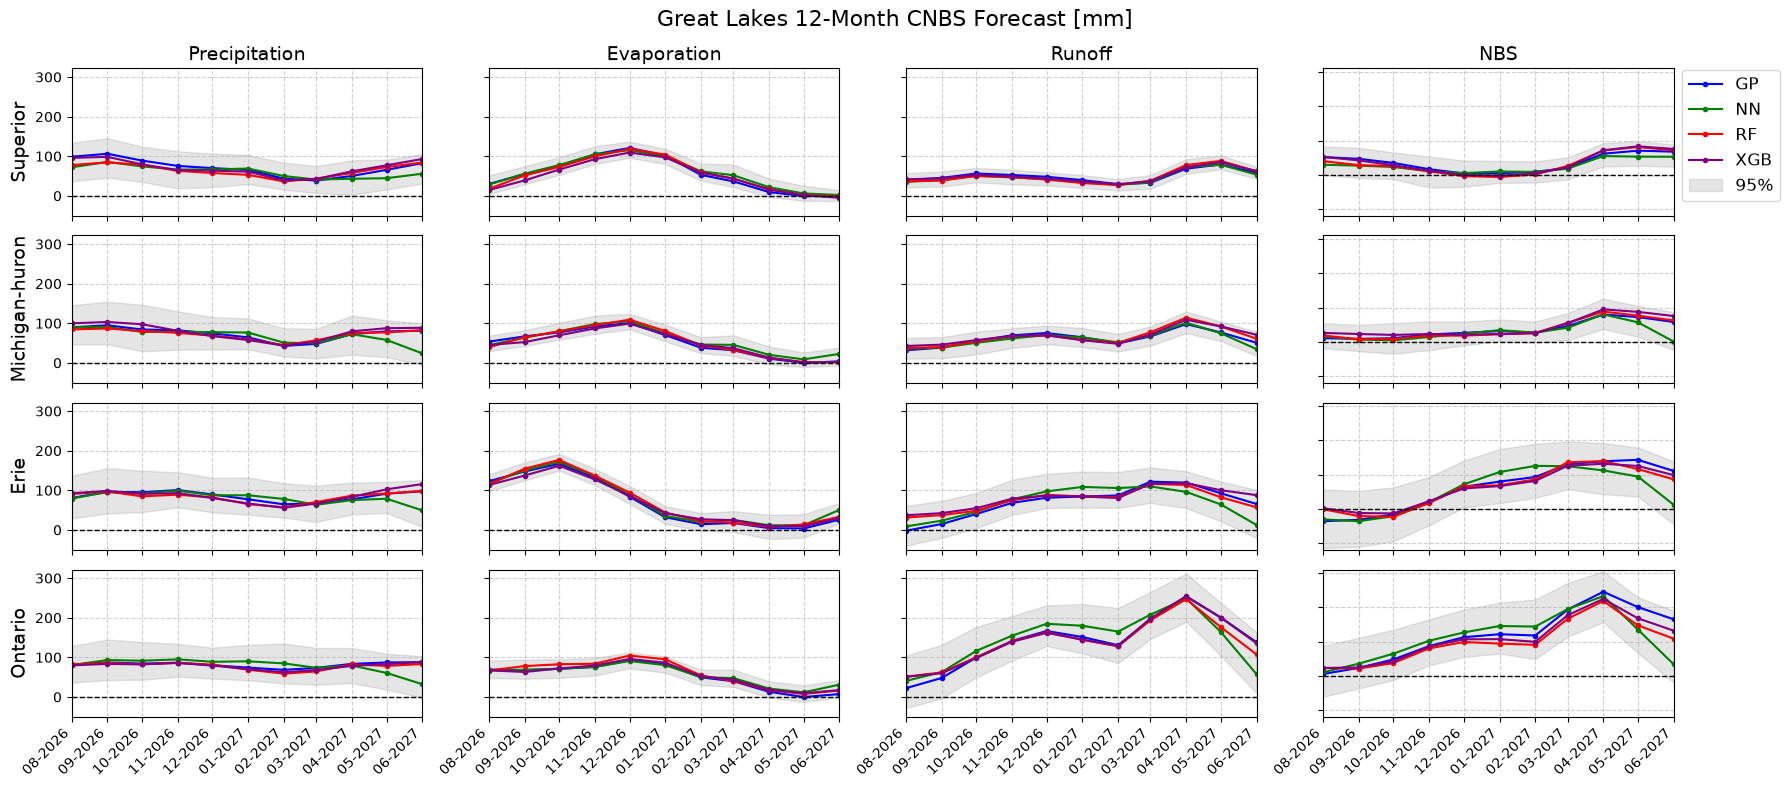

In [6]:
fig1 = plot_cnbs_forecast(df_filtered, filename=input_dir + "forecast/figures/cnbs_forecast.png", units="mm")

In [7]:
def plot_cnbs_forecast_interactive(df, filename=None, units="mm"):
    """
    Interactive Plotly plot for Great Lakes CNBS forecasts.

    Parameters
    ----------
    df : pd.DataFrame
        Long-format dataframe with columns:
        ["cfs_run", "forecast_month", "model", "lake", "component",
         "value [mm]", "value [cms]"]

    filename : str, optional
        File path for saving the interactive HTML. Defaults to None.

    units : str, default="mm"
        Units to plot:
        - "mm"  : uses "value [mm]"
        - "cms" : uses "value [cms]"
    """

    df = df.copy()

    # Select units
    if units.lower() == "mm":
        value_col = "value [mm]"
        units_label = "mm"
    elif units.lower() == "cms":
        value_col = "value [cms]"
        units_label = "cms"
    else:
        raise ValueError("units must be either 'mm' or 'cms'")

    # Convert forecast month to datetime
    df["date"] = pd.to_datetime(
        df["forecast_month"],
        format="%Y-%m"
    )

    models_info = df["model"].unique().tolist()

    custom_colors = [
        'blue', 'green', 'red', 'purple', 'orange',
        'brown', 'pink', 'olive', 'cyan', 'magenta'
    ]

    if len(models_info) > len(custom_colors):
        raise ValueError(
            f"Number of models ({len(models_info)}) exceeds available colors "
            f"({len(custom_colors)})."
        )

    model_colors = {
        model: custom_colors[i]
        for i, model in enumerate(models_info)
    }

    lakes = [
        "superior",
        "michigan-huron",
        "erie",
        "ontario"
    ]

    components = [
        "precipitation",
        "evaporation",
        "runoff",
        "nbs"
    ]

    # Create 4x4 subplot grid
    fig = make_subplots(
        rows=4,
        cols=4,
        subplot_titles=[
            "Precipitation",
            "Evaporation",
            "Runoff",
            "NBS"
        ],
        shared_xaxes=True,
        shared_yaxes=True,
        vertical_spacing=0.05,
        horizontal_spacing=0.008
    )

    global_y_min = float("inf")
    global_y_max = float("-inf")

    for row, lake in enumerate(lakes):

        for col, comp in enumerate(components):

            # Filter lake/component
            lake_df = df[
                (df["lake"] == lake) &
                (df["component"] == comp)
            ]

            if lake_df.empty:
                continue

            # 95% confidence bounds across all models
            lower = (
                lake_df
                .groupby("forecast_month")[value_col]
                .quantile(0.025)
                .reset_index()
            )

            upper = (
                lake_df
                .groupby("forecast_month")[value_col]
                .quantile(0.975)
                .reset_index()
            )

            lower["date"] = pd.to_datetime(
                lower["forecast_month"],
                format="%Y-%m"
            )

            upper["date"] = pd.to_datetime(
                upper["forecast_month"],
                format="%Y-%m"
            )

            for model_name in models_info:

                model_df = lake_df[
                    lake_df["model"] == model_name
                ]

                if model_df.empty:
                    continue

                mean_df = (
                    model_df
                    .groupby("forecast_month")[value_col]
                    .mean()
                    .reset_index()
                )

                mean_df["date"] = pd.to_datetime(
                    mean_df["forecast_month"],
                    format="%Y-%m"
                )

                # Confidence interval shading
                fig.add_trace(
                    go.Scatter(
                        x=pd.concat(
                            [
                                mean_df["date"],
                                mean_df["date"][::-1]
                            ]
                        ),
                        y=pd.concat(
                            [
                                lower[value_col],
                                upper[value_col][::-1]
                            ]
                        ),
                        fill="toself",
                        fillcolor="rgba(169,169,169,0.2)",
                        line=dict(
                            color="rgba(255,255,255,0)"
                        ),
                        showlegend=False,
                        hovertemplate=(
                            "Date: %{x}<br>"
                            "95% interval<br>"
                            "Value: %{y}"
                        )
                    ),
                    row=row+1,
                    col=col+1
                )

                # Mean model line
                fig.add_trace(
                    go.Scatter(
                        x=mean_df["date"],
                        y=mean_df[value_col],
                        mode="lines+markers",
                        name=model_name,
                        line=dict(
                            shape="linear",
                            width=2,
                            color=model_colors[model_name]
                        ),
                        marker=dict(size=4),
                        showlegend=(
                            row == 0 and col == 0
                        ),
                        hovertemplate=(
                            "Date: %{x}<br>"
                            f"{units_label}: %{{y}}<br>"
                            "Model: " + model_name
                        )
                    ),
                    row=row+1,
                    col=col+1
                )

                global_y_min = min(
                    global_y_min,
                    lower[value_col].min()
                )

                global_y_max = max(
                    global_y_max,
                    upper[value_col].max()
                )

            # Zero reference line
            fig.add_trace(
                go.Scatter(
                    x=[
                        lake_df["date"].min(),
                        lake_df["date"].max()
                    ],
                    y=[0, 0],
                    mode="lines",
                    line=dict(
                        color="black",
                        dash="dash"
                    ),
                    showlegend=False
                ),
                row=row+1,
                col=col+1
            )

            # Axis formatting
            fig.update_xaxes(
                tickformat="%m-%Y",
                tickangle=-45,
                showticklabels=(row == 3),
                showline=True,
                linewidth=2,
                linecolor="black",
                row=row+1,
                col=col+1
            )

            fig.update_yaxes(
                title_text=lake.title() if col == 0 else None,
                showline=True,
                linewidth=2,
                linecolor="black",
                row=row+1,
                col=col+1
            )

    # Consistent y-axis limits
    for r in range(1, 5):
        for c in range(1, 5):
            fig.update_yaxes(
                range=[
                    global_y_min - 10,
                    global_y_max + 10
                ],
                row=r,
                col=c
            )

    # Gridlines
    fig.update_yaxes(
        showgrid=True,
        gridwidth=0.5,
        gridcolor="LightGray"
    )

    fig.update_xaxes(
        showgrid=True,
        gridwidth=0.5,
        gridcolor="LightGray"
    )

    # Layout
    fig.update_layout(
        title_text=f"Great Lakes 12-Month CNBS [{units_label}] Forecast",
        title_x=0.5,
        height=800,
        width=1500,
        showlegend=True,
        legend=dict(
            x=1.01,
            y=1.01,
            traceorder="normal",
            orientation="v",
            title="Model"
        ),
        plot_bgcolor="white"
    )

    # Save
    if filename:
        os.makedirs(
            os.path.dirname(filename),
            exist_ok=True
        )
        fig.write_html(filename)

    fig.show()

## Plot 2
### **Interactive 4×4 Grid of Great Lakes 12-Month NBS Forecasts**

This section uses **Plotly** to create a fully interactive **4×4 subplot grid** that visualizes the mean forecasts and uncertainty ranges for precipitation, evaporation, runoff, and total CNBS across the four Great Lakes basins.

In [8]:
fig2 = plot_cnbs_forecast_interactive(df_filtered, filename=input_dir + 'forecast/figures/CNBS_forecast.html', units="mm")

## Plot 3

### **NBS forecast with Climatology**

This section focuses on the NBS forecast, same as above, but adds the climatology for an easy visual of whether the forecast is expected to be above or below climatology.

In [9]:
prob = DataLoader().lake_probabilities(probability_dir, units="mm")
prob_aligned = CEPCalculator(prob).align_prob_with_start_date(start_date)

In [10]:
def plot_nbs_forecast(df_filtered, prob, filename=None, units="mm"):
    """
    Plot NBS forecasts for the Great Lakes with ensemble model lines,
    95% range, and climatology.

    Parameters
    ----------
    df_filtered : pd.DataFrame
        Long-format forecast data containing:
        'forecast_month', 'lake', 'model', 'component',
        'value [mm]', and 'value [cms]'.

    prob : pd.DataFrame
        Probability of exceedance data containing:
        'date', 'lake', 'prob_exceedance', and 'value'.

    filename : str, optional
        Path to save the PNG.

    units : str, default="mm"
        Units to plot:
        - "mm"  uses 'value [mm]'
        - "cms" uses 'value [cms]'
    """

    # Select units
    if units.lower() == "mm":
        value_col = "value [mm]"
        units_label = "mm"
    elif units.lower() == "cms":
        value_col = "value [cms]"
        units_label = "cms"
    else:
        raise ValueError("units must be either 'mm' or 'cms'")

    # Copy dataframe
    df = df_filtered.copy()

    # Only plot NBS
    df = df[df["component"].str.lower() == "nbs"].copy()

    if df.empty:
        raise ValueError("No NBS data found in dataframe.")

    # Convert dates
    df["date"] = pd.to_datetime(
        df["forecast_month"],
        format="%Y-%m"
    )

    # Unique models
    models_info = df["model"].unique().tolist()

    # Colors
    custom_colors = [
        'blue', 'green', 'red', 'purple', 'orange',
        'brown', 'pink', 'olive', 'cyan', 'magenta'
    ]

    if len(models_info) > len(custom_colors):
        raise ValueError(
            f"Number of models ({len(models_info)}) exceeds available colors "
            f"({len(custom_colors)}). Add more colors."
        )

    model_colors = {
        model: custom_colors[i]
        for i, model in enumerate(models_info)
    }

    lakes = [
        "superior",
        "michigan-huron",
        "erie",
        "ontario"
    ]

    # Begin plotting
    fig, axs = plt.subplots(
        len(lakes),
        1,
        figsize=(10, 12),
        squeeze=False
    )

    fig.suptitle(
        f"Great Lakes 12-Month NBS [{units_label}] Forecast",
        fontsize=16,
        x=0.2,
        ha="left"
    )

    shared_y_min = float("inf")
    shared_y_max = float("-inf")

    for row, lake in enumerate(lakes):

        ax = axs[row, 0]

        lake_df = df[df["lake"] == lake]

        if lake_df.empty:
            continue

        # Confidence intervals
        lower = (
            lake_df
            .groupby("forecast_month")[value_col]
            .quantile(0.025)
            .reset_index()
        )

        upper = (
            lake_df
            .groupby("forecast_month")[value_col]
            .quantile(0.975)
            .reset_index()
        )

        lower["date"] = pd.to_datetime(
            lower["forecast_month"],
            format="%Y-%m"
        )

        upper["date"] = pd.to_datetime(
            upper["forecast_month"],
            format="%Y-%m"
        )

        # Plot each model
        for model_name in models_info:

            model_df = lake_df[
                lake_df["model"] == model_name
            ]

            if model_df.empty:
                continue

            mean_df = (
                model_df
                .groupby("forecast_month")[value_col]
                .mean()
                .reset_index()
            )

            mean_df["date"] = pd.to_datetime(
                mean_df["forecast_month"],
                format="%Y-%m"
            )

            ax.plot(
                mean_df["date"],
                mean_df[value_col],
                marker="o",
                markersize=3,
                color=model_colors[model_name],
                label=model_name
            )

        # 95% range
        ax.fill_between(
            lower["date"],
            lower[value_col],
            upper[value_col],
            color="gray",
            alpha=0.2,
            label="95%"
        )

        # Climatology (PoE = 0.5)
        lake_prob = prob.query(
            f"lake == '{lake}' and prob_exceedance == 0.5"
        )

        if not lake_prob.empty:
            lake_prob = lake_prob.copy()
            lake_prob["date"] = pd.to_datetime(lake_prob["date"])

            ax.plot(
                lake_prob["date"],
                lake_prob["value"],
                color="black",
                linestyle="--",
                linewidth=2,
                label="Climatology"
            )

        # Formatting
        ax.axhline(
            0,
            color="black",
            linestyle="--",
            linewidth=1
        )

        ax.grid(
            True,
            linestyle="--",
            alpha=0.6
        )

        ax.set_xlabel("")

        # Track y limits
        shared_y_min = min(
            shared_y_min,
            lower[value_col].min()
        )

        shared_y_max = max(
            shared_y_max,
            upper[value_col].max()
        )

        if row == len(lakes)-1:
            ax.xaxis.set_major_formatter(
                mdates.DateFormatter("%m-%Y")
            )
            ax.tick_params(
                axis="x",
                rotation=45
            )

            for label in ax.get_xticklabels():
                label.set_horizontalalignment("right")
        else:
            ax.set_xticklabels([])

        ax.set_ylabel(
            lake.title(),
            fontsize=14
        )

    # Apply common y-axis
    for ax in axs[:, 0]:
        ax.set_ylim(
            shared_y_min - 10,
            shared_y_max + 10
        )
        ax.set_xlim(
            df["date"].min(),
            df["date"].max()
        )

    # Legend only on first subplot
    axs[0, 0].legend(
        loc="lower left",
        bbox_to_anchor=(1, 0.3),
        fontsize=12
    )

    for r in range(1, len(lakes)):
        if axs[r, 0].get_legend() is not None:
            axs[r, 0].legend_.remove()

    plt.tight_layout()

    if filename:
        os.makedirs(
            os.path.dirname(filename),
            exist_ok=True
        )
        plt.savefig(
            filename,
            bbox_inches="tight"
        )

    plt.show()

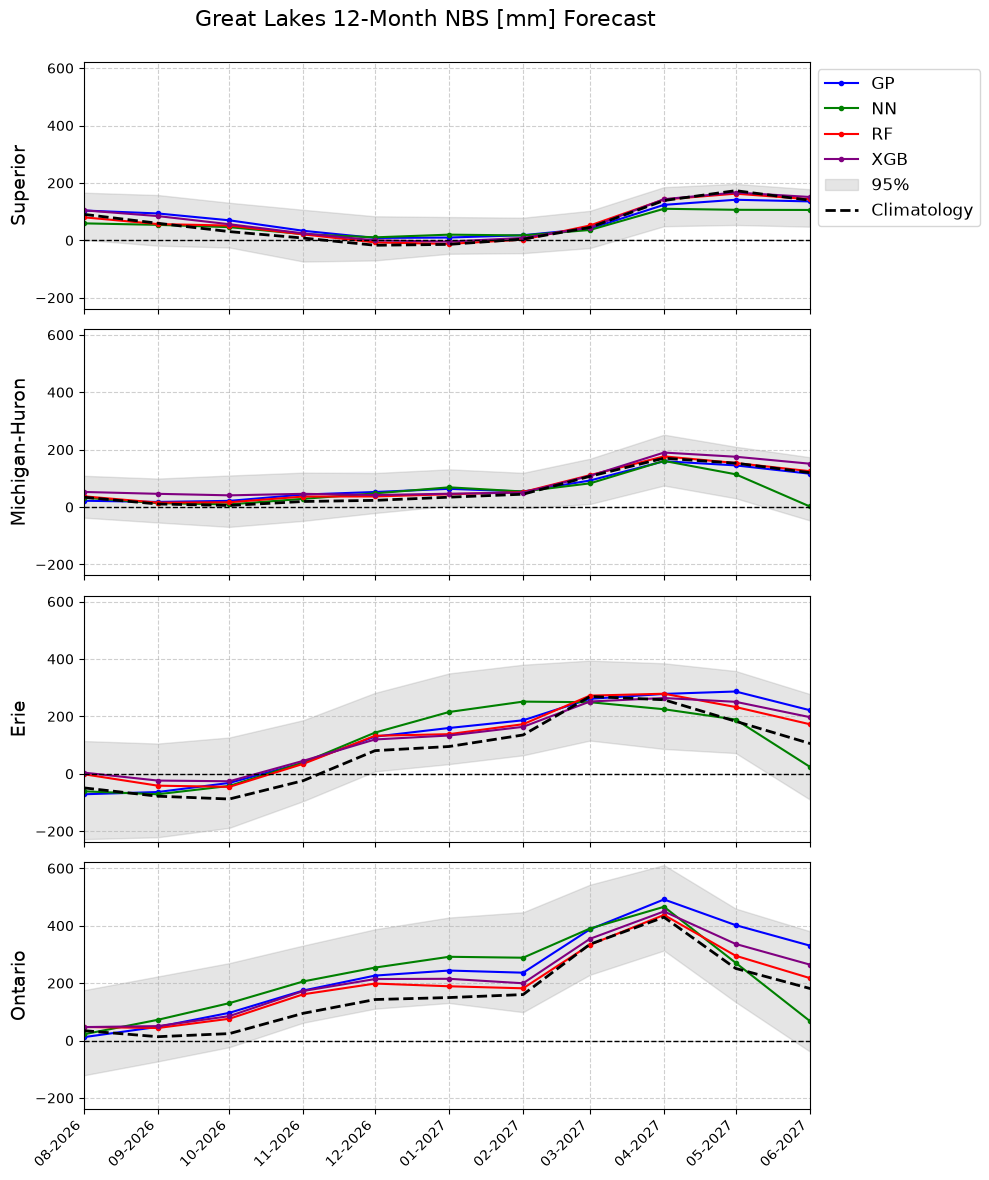

In [11]:
fig3 = plot_nbs_forecast(df_filtered, prob_aligned, input_dir + 'forecast/figures/NBS_forecast.png')

## Plot 4
### Plot **Climatology Exceedance Probability (CEP)** Time Series

**Climatology Exceedance Probability (CEP)**, or Probability of Exceedance (POE) as it it known by the USACE, is the fraction of historical climatological values that exceed a given forecast value for a specific variable, location, and time period. It quantifies where the forecast falls within the climatological distribution and is calculated as the probability that a climatological value is greater than the forecast value.

A higher CEP indicates a drier-than-normal forecast (lower forecast values relative to climatology), while a lower DEI indicates a wetter-than-normal forecast (higher forecast values relative to climatology).

The `plot_cep_timeseries()` function takes the calculated CEP dataframe (`ced_df`) and creates a visualization showing how each model compares to climatological conditions over the forecast period.

Plot characteristics:

- **X-axis:** Forecast month (12-month outlook)
- **Y-axis:** Climatology Exceedance Probability (0–1)
- **Lines:** Individual model forecasts
- **Reference line at 0.5:** Climatological normal

Interpretation:

- **CEP = 0.5** → Forecast is near climatology (normal conditions)
- **CEP > 0.5** → Forecast indicates drier-than-normal conditions
- **CEP < 0.5** → Forecast indicates wetter-than-normal conditions

This figure provides a quick way to compare model agreement and assess whether the forecast is trending toward unusually wet or dry conditions. Large separation between model lines indicates higher forecast uncertainty, while close agreement suggests greater confidence.

The figure is saved to:

`forecast/figures/ced_timeseries.png`

In [12]:
df_cep = pd.read_csv(prob_file, sep=',')

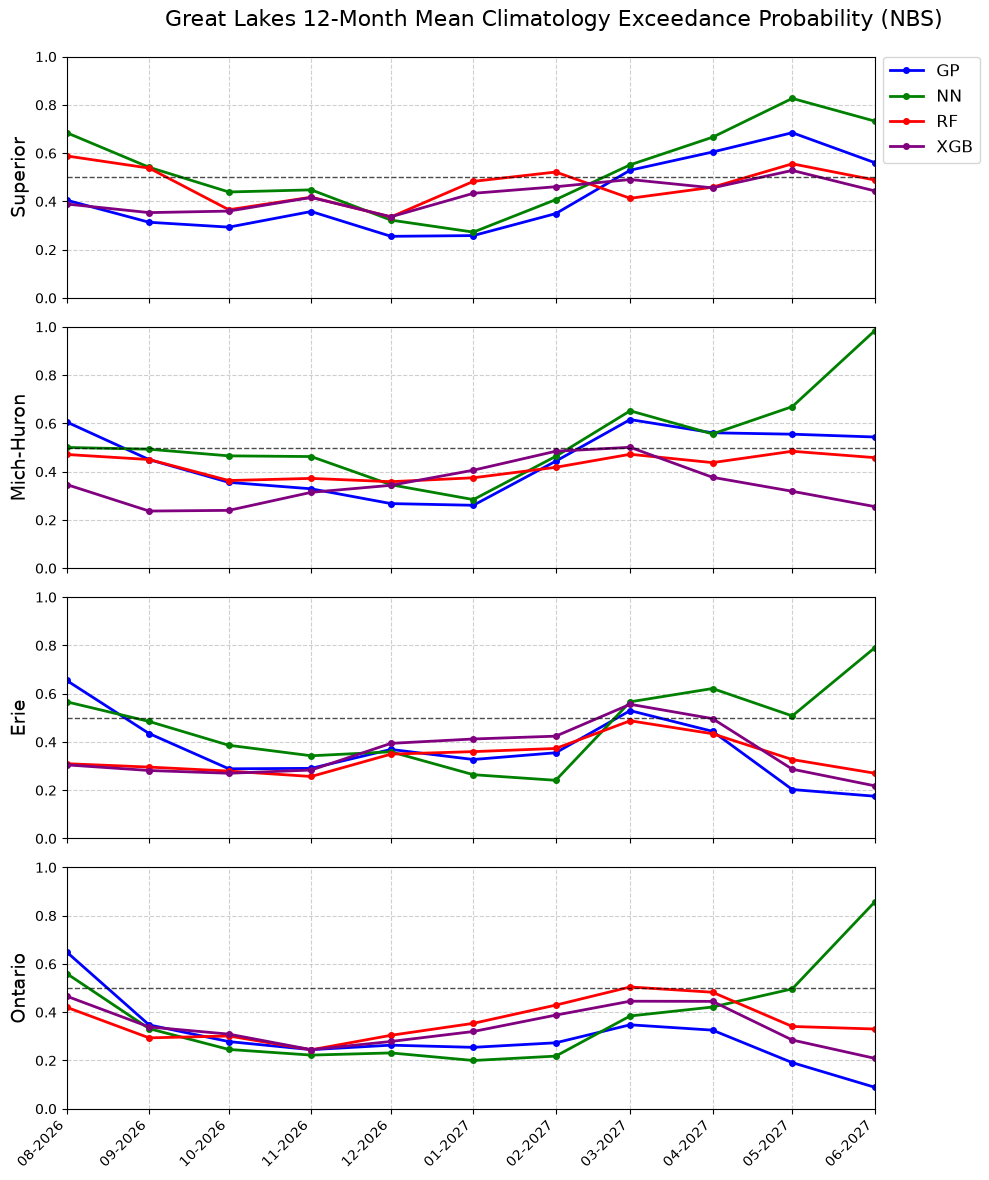

In [13]:
fig4 = plot_cep_timeseries(df_cep, input_dir + 'forecast/figures/cep_timeseries.png')

## Plot 5
### Plot **Climatology Exceedance Probability (CEP)** Spatial Maps

**Climatology Exceedance Probability (CEP)** is the fraction of historical climatological values that exceed a given forecast value for a specific variable, location, and time period. It quantifies where the forecast falls within the climatological distribution and is calculated as the probability that a climatological value is greater than the forecast value.

The `plot_cep_spatial_12month()` function creates a **3 × 4 panel figure**, where each subplot represents one forecast month in the 12-month outlook. In this example, the plot is generated using the **Random Forest (RF)** model but can be set based on the user.

Function inputs:

- **`cep_df`**: Dataframe containing calculated CEP values for each lake, forecast month, and model
- **`model="RF"`**: Selects the Random Forest model for visualization
- **`filename`**: Output file path for saving the figure

Plot characteristics:

- **Layout:** 3 rows × 4 columns (12 forecast months)
- **Each subplot:** One forecast month
- **Shaded regions:** Great Lakes colored by POE anomaly
- **Color scale:** Diverging brown-to-blue colormap

Color interpretation:

- **Dark brown (high values)** → Drier-than-normal conditions  
- **White / neutral** → Near climatological normal  
- **Dark blue (low values)** → Wetter-than-normal conditions   

This spatial plot provides a quick visual summary of how wet or dry conditions evolve across the Great Lakes over the forecast horizon and helps identify lake-specific anomalies and regional patterns.

The figure is saved to:

`forecast/figures/climatology_exceedance_spatial_RF.png`

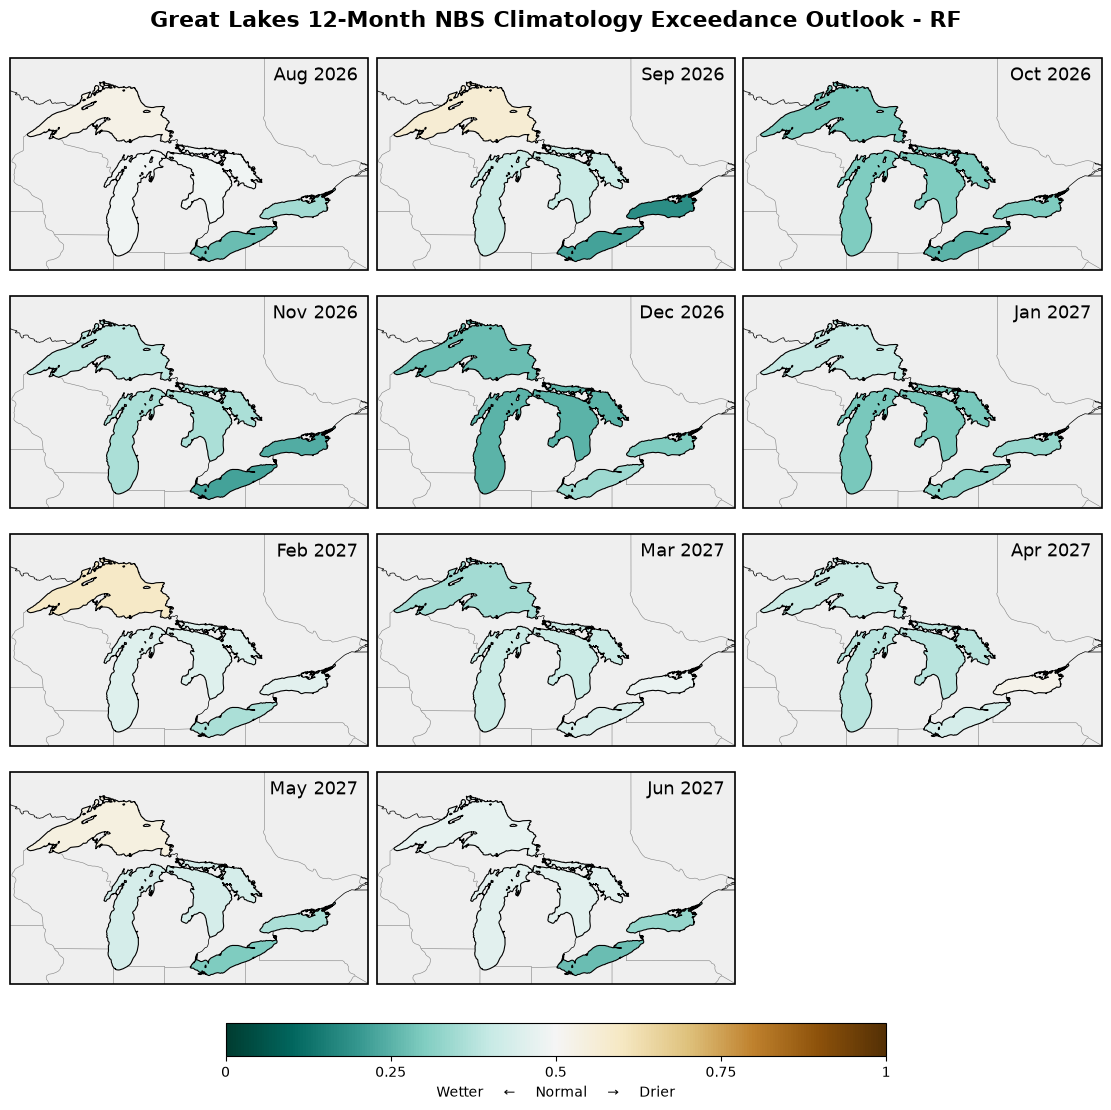

In [14]:
fig5 = plot_cep_spatial(
    df_cep=df_cep,
    model="RF",
    value_col="cep",
    filename=input_dir + 'forecast/figures/climatology_exceedance_spatial_RF.png'
)